# 3.2 Brand classification with transfer learning and angle information. 

In [1]:
import pandas as pd
import os
import sys
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #, accuracy_score, f1_score, cohen_kappa_score

sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
import numpy as np
import style
# import matplotlib.pyplot as plt
import implot




2025-05-04 12:38:30.114696: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 3.2.1 Preparing the system
- Setting constants to us in this notebook and GPU override. 
- Reading config file - no database connection needed as data comes from CSVs

In [2]:
SHAPE = 224   #required for resnet
BATCH_SIZE = 32     #how big ar teh batches for the online learning part
MAX_EPOCHS = 100    #upper limit of epochs per learning task - 
                    #    NOTE THAT there is early stopping and lr plateau just as in nobteook 2.

PHASE = 'brand phase'

In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-04 12:38:32.106065: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:34.482017: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:34.482099: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
config = Configloader()

basedir = config.get('settings', 'image_directory')


basedir = config.get('settings', 'image_directory')
augmdir = config.get('dir_augmentations', 'subfolder')
augmcsv = config.get('dir_augmentations', 'csv_dir')



augment_base = os.path.join(basedir, augmdir, PHASE)
augment_csv_dump = os.path.join(basedir, augmcsv, PHASE)


In [5]:
#local functions: 

def get_brands_by_augmented_data(df):
    """returns a sorted list of brandnames from least to most augmented data volume
    argument    
        df = dataframe of trainingsdata with abs_path and brand column required!
    """
    all_brands = df.brand.unique()
    filtered_df = df[df['abs_path'].str.contains('augmentated data', case=False, na=False)]
    brand_counts = filtered_df['brand'].value_counts()
    sorted_brands = brand_counts.index.tolist()
    for brand in all_brands:
        if brand not in sorted_brands: 
            sorted_brands.append(brand)
    sorted_brands = sorted_brands[::-1]
    #print(brand_counts)
    return sorted_brands

def interval_select(objects, n):
    """
        Returns a list of n-length with items taken out of objects evenly spaced. 
        eg. :   objects = [1,2,3,4,5,6,7,8,9]
                n=3
                will return 1,5,9
        returns are approximately with a skew at the end.; 
        e.g.    n = 4
                will return 1, 4, 6, 9 
    """
    if len(objects) < n:
        raise ValueError("The list must have at least 'n' elements.")
    idxs= [0]  #first index
    step = (len(objects) - 1) / (n - 1)
    for i in range(1, n - 1):
        idxs.append(round(i * step))
    idxs.append(len(objects) - 1) #last indes
    return [objects[i] for i in idxs]

## 3.2.2 Data loading
Load the CSV's generated by step 3.1 into memory. 

If KERAS would've been able of using integers; then the 300.000 images per angle would've fit in memory: you'd need about 45GB; with the floats however you need about 4 times more! So here too you'll be required to use batch learning. 

In [6]:
traindata = pd.read_csv(os.path.join(augment_csv_dump, 'traindata_brandphase.csv'))
testdata = pd.read_csv(os.path.join(augment_csv_dump, 'testdata_brandphase.csv'))

In [7]:
angles = traindata['model_label'].unique()

## 3.2.3 Deciding on cropping or not: TRAINING

There's reason to assume that cropping according to the provided bounding boxes will yield the best results. We'll test this assumption using data for the front-angle view and 5 brands. These 5 brands will be chosen based on an even distribution of augmented data. i.e. we'll first calculate how many of the 10.000 records per brand are augmented, sort them and then select at even intervals. We'll be doing this small experiment here and apply the outcome of this in all `3.y`-notebooks. 

In [8]:
traindata.sample(3)

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
1130396,11650732,frontleft,1.000000,190,267,955,568,11650732,0.988543,0.914138,0.329300,0.605378,lotus,/home/frederic/Documents/automotive_image_data...
1926607,2454105,front,0.999949,-1,-1,-1,-1,2454105,0.659432,0.999965,0.993781,0.989331,skoda,/home/frederic/Documents/automotive_image_data...
962338,10360466,front,0.999897,-1,-1,-1,-1,10360466,0.901022,0.999908,0.948476,0.988805,land-rover,/home/frederic/Documents/automotive_image_data...


For this mini-experiment, we'll do a small subselection of the data, this subselection will allow for quicker testing of the resnet learner that's planned on being used here. And will also allow testing whether or not cropping an image is beneficient or not. Just as in notebook `2`, there will be no extra model trained that applied a padded crop. 

We do this in a loop to allow us to extend the test if we're interested at some point. 

Just as you'd normally do, we'll be going through all the hoops of training: 
- Unlike notebook `2`, here we can use a simple labelencoder - there's no order we want to visualize later or adjacentness to keep in mind. We'll also shuffle the notebook and return to conventional Xy notation for df names.
- Notice that the data gets shuffled!! Up untill this point the traindata are 30 blocks of 80.000 images per brand!! 
- Class balances are taken care of in the previous step at notebook `3.1`; the same is true for the train-test split. 

In [9]:
experiment_values = [True, False]       #values to test for crop argument.
brands_in_experiment = 5                #how many brands in this experiment
chosen_angle_croptest = ['front']       #if we ever want to test multiple angles, this can be extended

model_dest_dir = os.path.join(os.getcwd(), '..', '..', 'models', 'brand_models')
os.makedirs(model_dest_dir, exist_ok=True)

for angle in chosen_angle_croptest: 
    view_by_angle = traindata.query('model_label==@angle')
    brands_desc = get_brands_by_augmented_data(view_by_angle)
    selected_brands = interval_select(brands_desc, brands_in_experiment)
    small_df_train = view_by_angle[view_by_angle['brand'].isin(selected_brands)].copy()
    small_df_test = testdata.query('model_label==@angle')
    small_df_test = small_df_test[small_df_test['brand'].isin(selected_brands)].copy()
    #Shuffle train and test set. 
    small_df_train = cnn_helpers.shuffle_df(small_df_train)
    small_df_test = cnn_helpers.shuffle_df(small_df_test)
    # apply label encoding: we need to redo this for every iteration of the loop 
    #   as you can't be sure selected_brands is always the same!!
    tiny_label_encoder = LabelEncoder()
    tiny_label_encoder.fit(selected_brands)
    small_df_train['y_encoded'] = tiny_label_encoder.transform(small_df_train['brand'])
    small_df_test['y_encoded'] = tiny_label_encoder.transform(small_df_test['brand'])
    # Conventional naming schemes: Xy-notatation for train and test 
    #   rememember that traintestsplit is already done and was frozen
    #   because of the CSV dump. 
    X_train, y_train = cnn_helpers.get_X_y(small_df_train, 'y_encoded', ['brand'])
    X_test, y_test = cnn_helpers.get_X_y(small_df_test, 'y_encoded', ['brand'])
    for crop in experiment_values:
        name = f'TINY_brand_model-Resnet50_cropped={crop}.keras'
        if name in os.listdir(model_dest_dir):
            print(f"Skipping {name} -- model already trained")
            continue
        model = cnn_helpers.resnet_learner(X_train, X_test, y_train, y_test, SHAPE, crop, model_dest_dir, BATCH_SIZE, MAX_EPOCHS)
        model.save(os.path.join(model_dest_dir, name))



Skipping TINY_brand_model-Resnet50_cropped=True.keras -- model already trained
Skipping TINY_brand_model-Resnet50_cropped=False.keras -- model already trained


## 3.2.4 Deciding on cropping or not: EVALUATION

Over eight hours was needed to loop over 50.000 images twice, it's a good call to test whether or not cropping helps on a small set in stead of the full dataset. I'll not spend a large amount of resources on this evaluation: If a simple confusion matrix shows a clear enough difference, then this is what will be used. One important bit to look at, is to see if brands with high augmentation volumns (such as Alpine) score worse or not. With the outcome of this test, the computer can run attended for a longer time if needed to process all of the 300.000 images that are available per angle. 

In [10]:
##let's go over the validation set here - testset was used already in 3.2.3 - the validation set however is 
# unseen data for the model. It should be a good test.

validationdata = pd.read_csv(os.path.join(augment_csv_dump, 'validationdata_brandphase.csv'))
#vd still has 30 brands and was only trained on frontal views:  make the subselect!!!!
validationdata_front = validationdata.query('model_label=="front"')
validationdata_front = validationdata_front[validationdata_front['brand'].isin(selected_brands)].copy()

#with subselect applied: encode
validationdata_front['y_encoded'] = tiny_label_encoder.transform(validationdata_front['brand'])

X, y = cnn_helpers.get_X_y(validationdata_front, 'y_encoded', ['brand'])
X = cnn_helpers.cast_bbox_values(X)

In [11]:
X.sample(5)

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,abs_path
292881,13068351,front,1.0,150,31,630,424,13068351,0.972124,0.999977,0.978098,0.994427,/home/frederic/Documents/automotive_image_data...
343390,4488226,front,1.0,145,71,521,395,4488226,0.995041,1.000000,0.997800,0.988225,/home/frederic/Documents/automotive_image_data...
268617,9794584,front,1.0,45,7,670,551,9794584,0.974703,0.999997,0.994216,0.984216,/home/frederic/Documents/automotive_image_data...
377555,4132890,front,1.0,134,28,587,437,4132890,0.975030,0.998925,0.784963,0.995110,/home/frederic/Documents/automotive_image_data...
201136,11016613,front,1.0,128,79,635,498,11016613,0.988361,0.999039,0.974455,0.982995,/home/frederic/Documents/automotive_image_data...


2025-05-04 12:38:40.555237: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:40.555423: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:40.555508: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:40.555629: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-04 12:38:40.555692: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

325/325 ━━━━━━━━━━━━━━━━━━━━ 37s 101ms/step


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
2025-05-04 12:40:09.542116: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 6246309888 exceeds 10% of free system memory.
2025-05-04 12:40:14.783580: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 6246309888 exceeds 10% of free system memory.


325/325 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step


/home/frederic/Documents/automotive_project/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


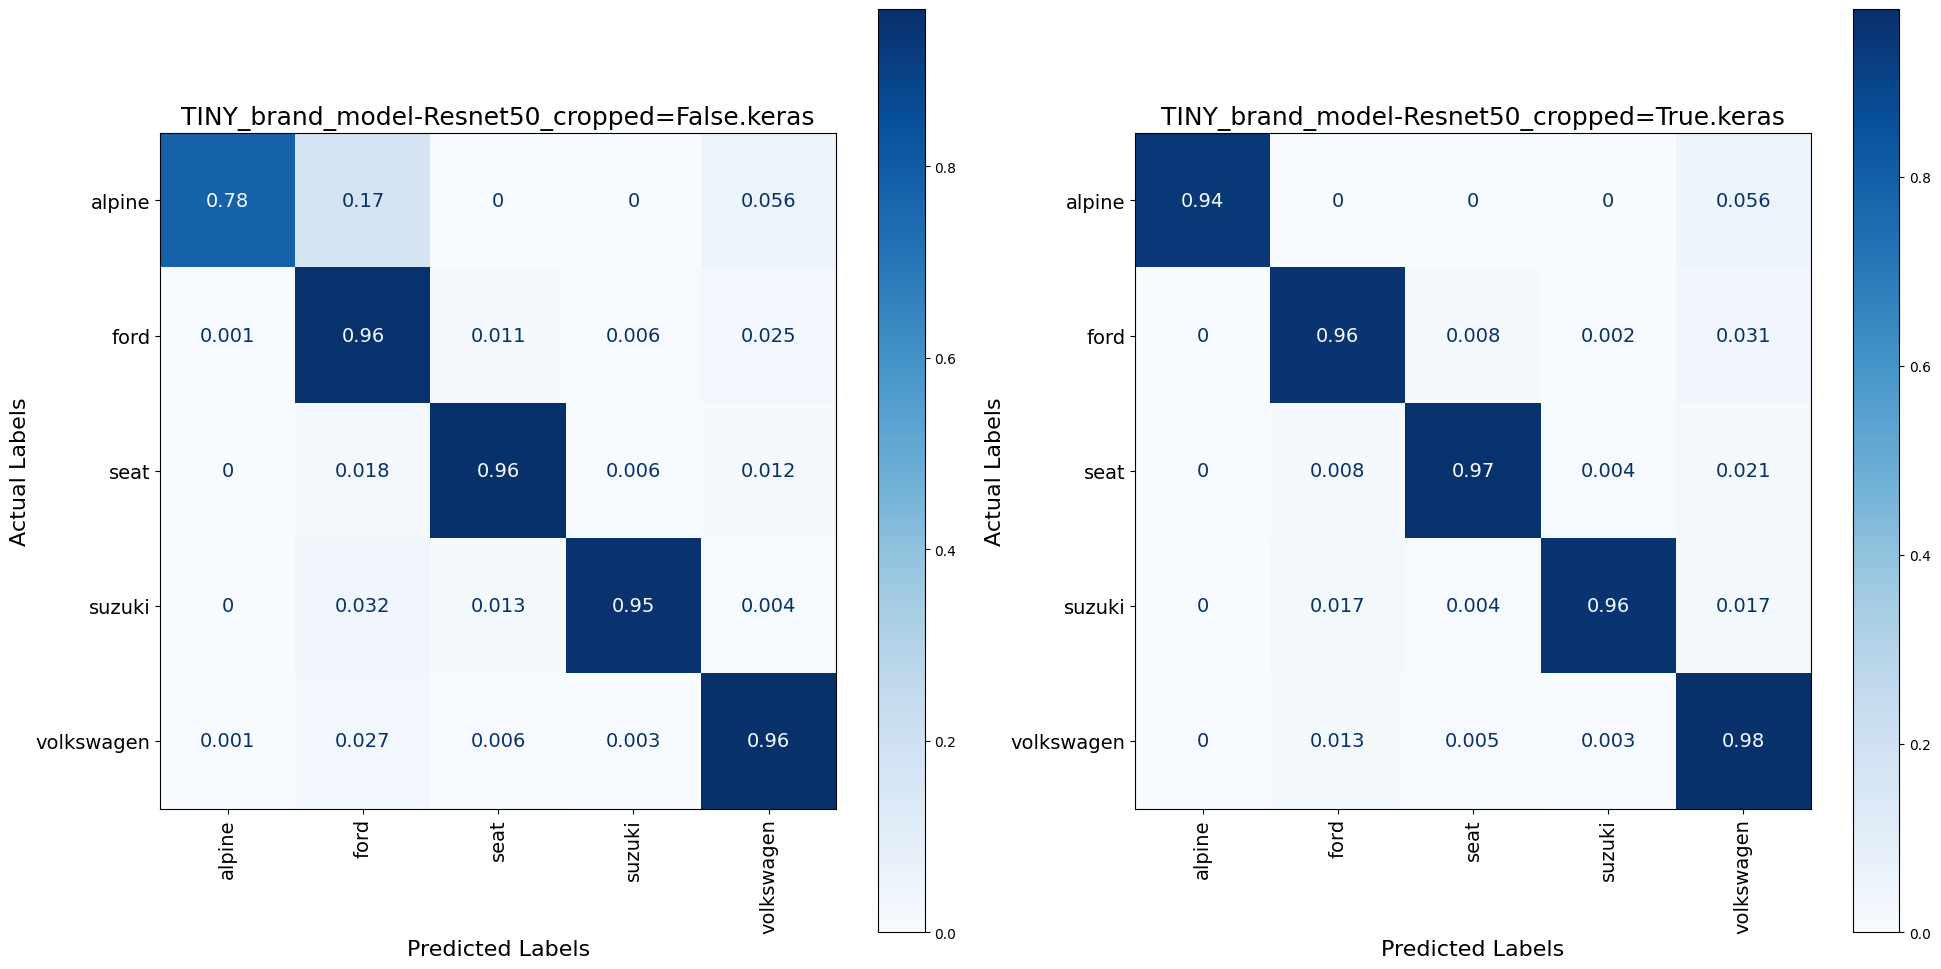

In [12]:
cms = {}
metrics = {}
predictions = {}
for modelname in os.listdir(model_dest_dir): 
    if 'TINY' in modelname:
        model = tf.keras.models.load_model(os.path.join(model_dest_dir, modelname))
        X_test_images = []
        for _, row in X.iterrows():
            coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
            image = cnn_helpers.preprocess_image(row['abs_path'], '=True' in modelname, coords, SHAPE)
            X_test_images.append(image)
        X_test_images = np.array(X_test_images)
        predicts = model.predict(X_test_images)
        predicts = np.argmax(predicts, axis=1)
        decoded_predicts = tiny_label_encoder.inverse_transform(predicts.reshape(-1, 1)).flatten()
        decoded_actuals = tiny_label_encoder.inverse_transform(y).flatten()
        confusion_on_y_test = pd.DataFrame(
            {
                'actuals': decoded_actuals,
                'predicts': decoded_predicts
            }
        )

        act = confusion_on_y_test['actuals']
        pred = confusion_on_y_test['predicts']
        
        if modelname not in predictions:
            predictions[modelname] = {}
        predictions[modelname]['actuals'] = act
        predictions[modelname]['predicts'] = pred
        shortname = modelname.split('_')[-1].split('.')[0]#cropped = false or true
        metrics[shortname] = implot.quick_metrics(act, pred)
        cm_disp = implot.make_cm(act, pred, tiny_label_encoder.inverse_transform(np.sort(y.unique())), embed=True)
        cms[modelname] = cm_disp
k1,k2 = cms.keys()

implot.side_by_side_cm(cms[k1], k1, cms[k2], k2, innersize= 14, labelsize=14)

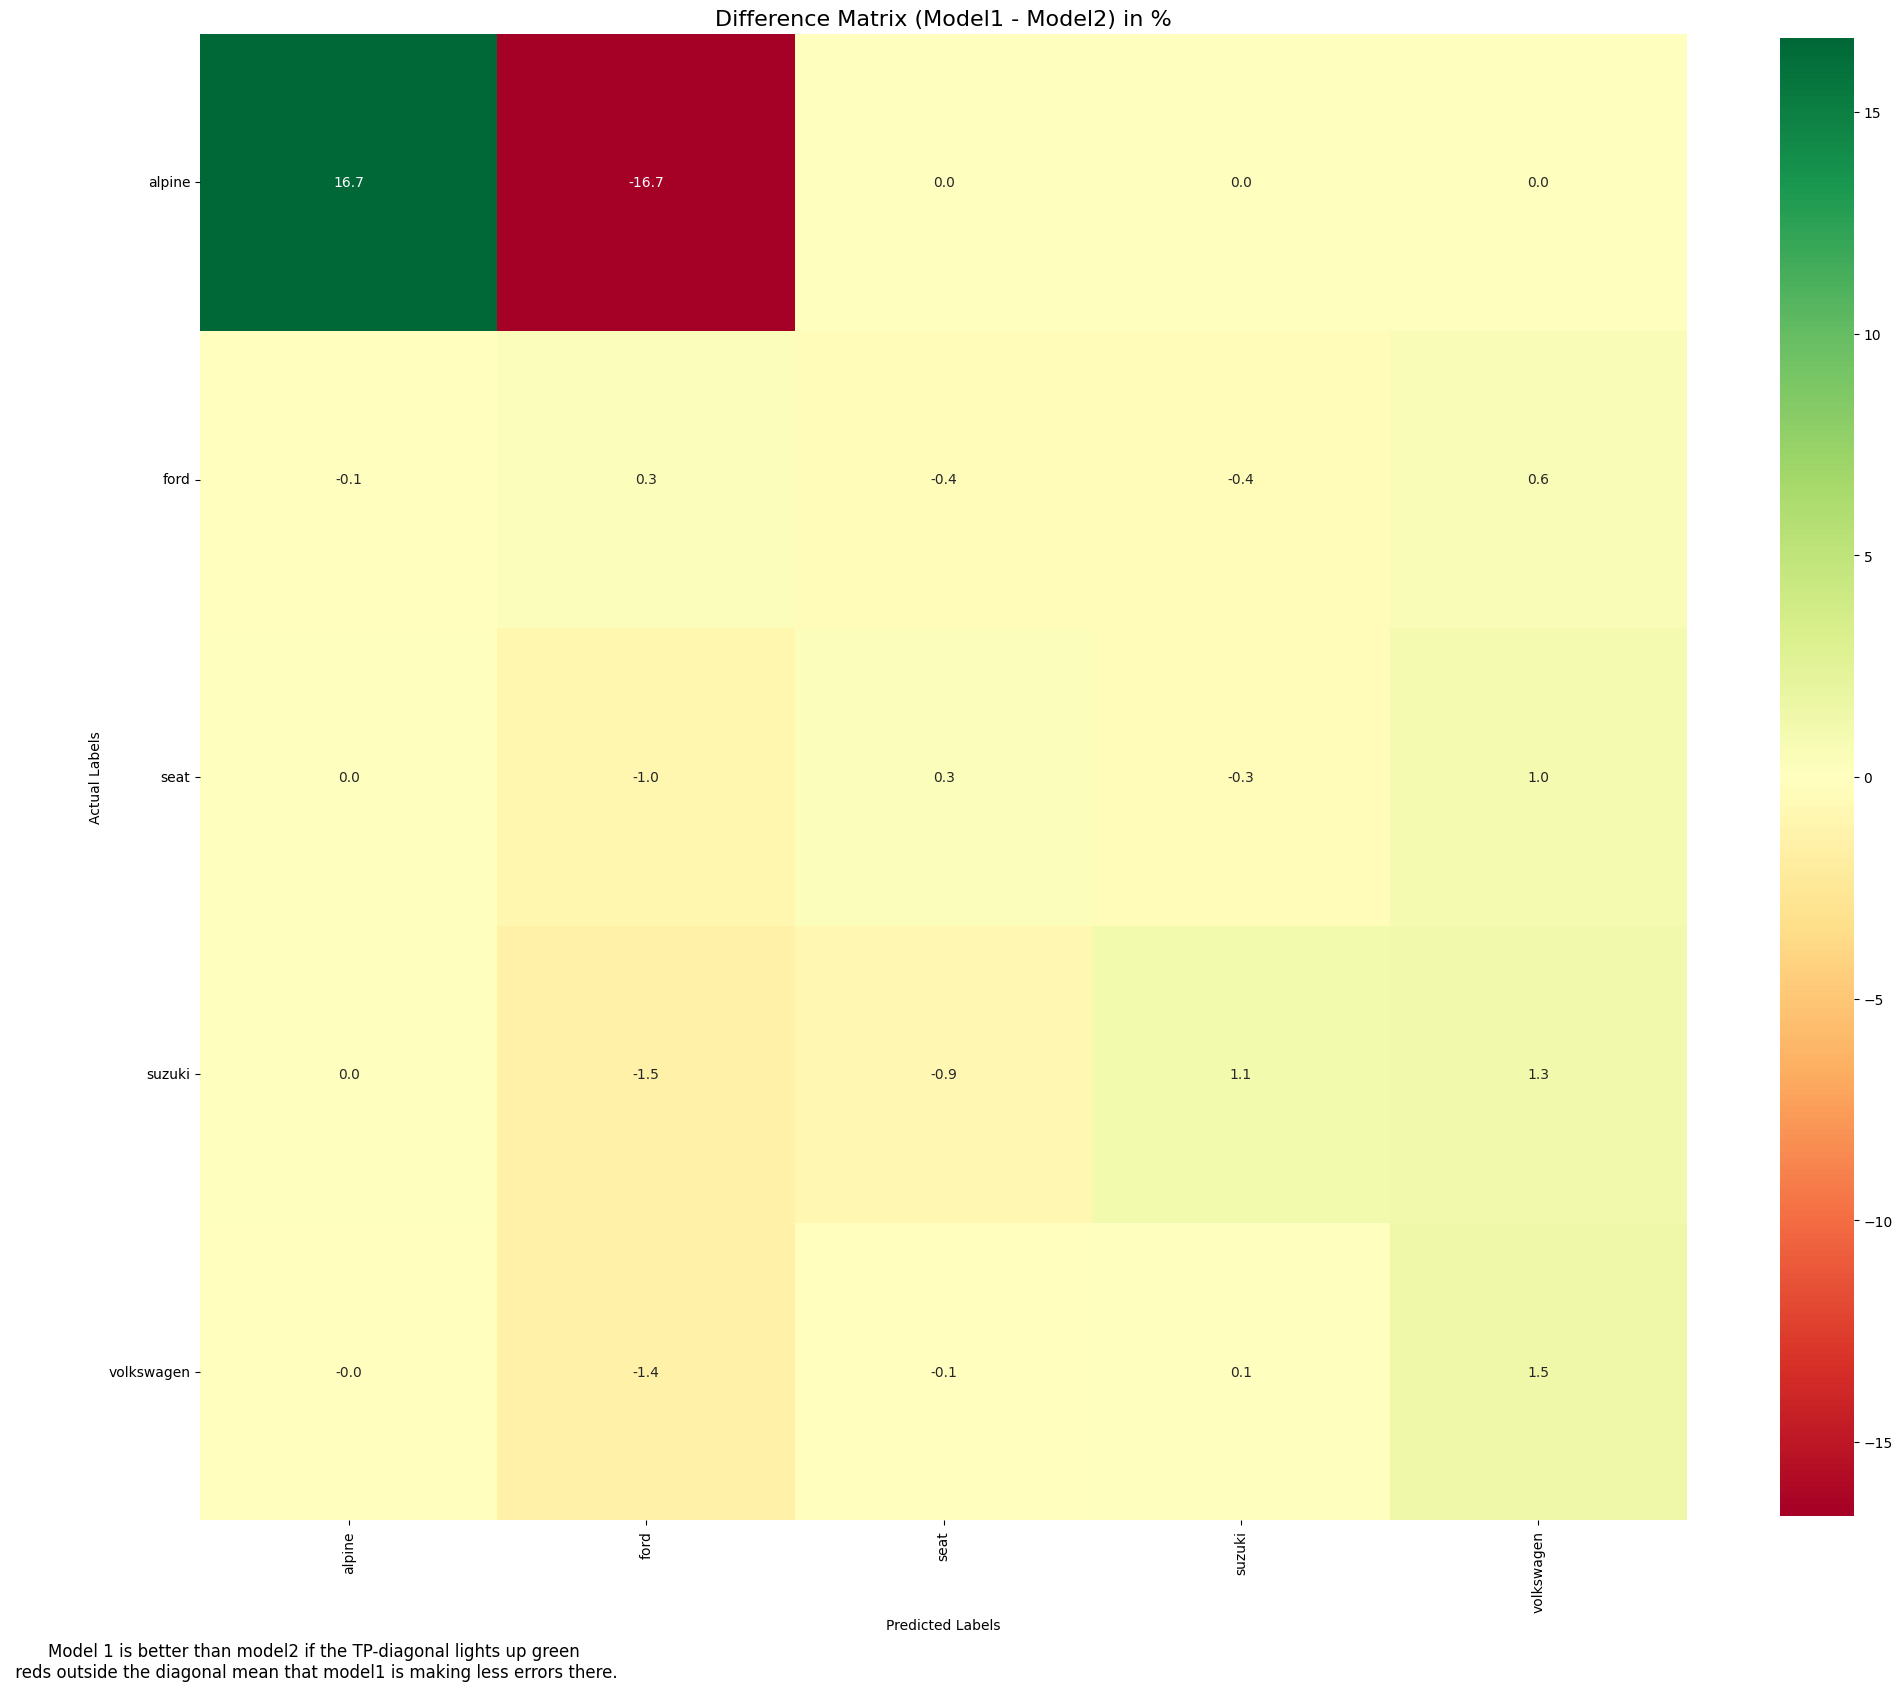

In [13]:
brand_names = tiny_label_encoder.inverse_transform(np.sort(y.unique()))
implot.cm_delta(predictions[k2]['predicts'], predictions[k1]['predicts'], predictions[k1]['actuals'], list(brand_names))
#k2 = model with crop applies: so across the diagonal there's a small improvement by using crops. 

In [14]:
#extract the diagonal: 
textObjects = {
    'title': 'Difference of cropping or not.',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}

implot.compare_model_accuracies(
    predictions[k2]['predicts'], predictions[k2]['actuals'], 
    predictions[k1]['predicts'], predictions[k1]['actuals'], 
    brand_names, textObjects
)

In [18]:
#pretty good indication that we should crop; let's verify with the metrics: 
mview = implot.plot_quick_metrics(metrics)
mview.update_layout(
    height= 1080, 
    width= 1920,
    title='Cropping or not on tinyset (CNN; Resnet50)'
)

Here the weighted scores are the most interesting to look at as they are not thrown off by the imbalence between Alpine and Volkswagen; all weighted metrics indicate that cropping is beneficial, this was already indicated by the `compare_model_accuracies` plot

## 3.2.5 Deciding on cropping or not: CONCLUSION: 
- There is a slight advantage in using cropped images. The effect of this is most pronounced on classes that required a lot of augmentation.
- highly augmented brands such as Alpine are not affected, there's still quite a low error rate; allthough it is higher than brands that didn't require augmentation (Volkswagen). 

So in conclusion with these two topics coming to a favourable conclusion, it is safe to proceed to phase `3.3` and learn on the full dataset. The code used in this notebook can be reused as the learner has been moved to the utilities. 

The decisions coming from training the tiny models are: 
1) ALWAYS apply cropping in phases `3.3`, `3.4`, `3.5`
2) Carry on with augmented data as is, I'm quite happy with the error rates. 
